In [116]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [117]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/hr-analytics-job-change-of-data-scientists")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hr-analytics-job-change-of-data-scientists' dataset.
Path to dataset files: /kaggle/input/hr-analytics-job-change-of-data-scientists


##Пункт 0: Описание задачи

Задача состоит в том, чтобы построить модель машинного обучения, которая сможет предсказать, ищет ли кандидат на должность специалиста по данным новую работу или нет.

Компания, проводящая курсы по Big Data и Data Science, хочет заранее определять, какие из слушателей действительно заинтересованы в работе в этой компании, а какие планируют сменить место работы после обучения. Это поможет компании сократить расходы, оптимизировать процесс обучения и более эффективно распределять ресурсы.

Входные данные — это демографическая информация, сведения об образовании и опыте кандидатов.Целевая переменная (то, что мы хотим предсказать) — target — бинарная:



1 — кандидат ищет новую работу.

0 — кандидат не ищет новую работу.



Таким образом, мы решаем задачу бинарной классификации и хотим спрогнозировать вероятноть того, что кандидат будет работать в компании.

--------

Тут пытался понять с чем имею дело и выяснил, что у меня target есть только в train и придется работать только с ним.

In [118]:
train_df = pd.read_csv(path+'/aug_train.csv')
test_df = pd.read_csv(path+'/aug_test.csv')
y_train_full = train_df['target'].copy()


train_features = train_df.drop('target', axis=1)

train_num_rows = len(train_features)

print(train_df.info())
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [119]:
print(y_train_full.info())
print(y_train_full.head())

<class 'pandas.core.series.Series'>
RangeIndex: 19158 entries, 0 to 19157
Series name: target
Non-Null Count  Dtype  
--------------  -----  
19158 non-null  float64
dtypes: float64(1)
memory usage: 149.8 KB
None
0    1.0
1    0.0
2    0.0
3    1.0
4    0.0
Name: target, dtype: float64


In [120]:
combined_df = pd.concat([train_features, test_df], ignore_index=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             21287 non-null  int64  
 1   city                    21287 non-null  object 
 2   city_development_index  21287 non-null  float64
 3   gender                  16271 non-null  object 
 4   relevent_experience     21287 non-null  object 
 5   enrolled_university     20870 non-null  object 
 6   education_level         20775 non-null  object 
 7   major_discipline        18162 non-null  object 
 8   experience              21217 non-null  object 
 9   company_size            14727 non-null  object 
 10  company_type            14513 non-null  object 
 11  last_new_job            20824 non-null  object 
 12  training_hours          21287 non-null  int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 2.1+ MB


--------

------
##Пункт 1: Прочитать данные

In [121]:
df = pd.read_csv(path+'/aug_train.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


##Пункт 2: Разбиение данных на обучающую и тестовую выборки

In [122]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (15326, 13)
Размер X_test: (3832, 13)
Размер y_train: (15326,)
Размер y_test: (3832,)


##Пункт 3: Визуализация данных и вычисление основных характеристик

In [123]:
sns.set(style="whitegrid")
print(train_df.describe())

        enrollee_id  city_development_index  training_hours        target
count  19158.000000            19158.000000    19158.000000  19158.000000
mean   16875.358179                0.828848       65.366896      0.249348
std     9616.292592                0.123362       60.058462      0.432647
min        1.000000                0.448000        1.000000      0.000000
25%     8554.250000                0.740000       23.000000      0.000000
50%    16982.500000                0.903000       47.000000      0.000000
75%    25169.750000                0.920000       88.000000      0.000000
max    33380.000000                0.949000      336.000000      1.000000


### Детальная интерпретация по колонкам:

#### **1. `enrollee_id` (ID кандидата)**

*   **`count` (количество):** 19158 записей. Пропусков нет.
*   **`mean`, `std`, `min`, `max`:** Эти значения для ID не несут никакого смысла.

#### **2. `city_development_index` (Индекс развития города)**

*   **`count`:** 19158 записей. Пропусков нет.
*   **`mean` (среднее):** 0.829. Средний индекс развития города довольно высокий (максимум близок к 1).
*   **`min` & `max`:** Индекс варьируется от 0.448 (очень низкий) до 0.949 (очень высокий).
*   **`50%` (медиана):** 0.903. Медиана выше, чем среднее (0.829). Это говорит о том, что распределение смещено влево.То есть большинство кандидатов (более 50%) живут в городах с очень высоким индексом развития (>0.9). Однако есть небольшое количество кандидатов из городов с очень низким индексом, и они "тянут" среднее значение вниз.

#### **3. `training_hours` (Часы обучения)**

*   **`count`:** 19158 записей. Пропусков нет.
*   **`mean` (среднее):** 65 часов. В среднем кандидат проходит около 65 часов обучения.
*   **`std` (стандартное отклонение):** 60. Очень большой разброс, почти равный среднему. Это говорит о том, что значения сильно варьируются.
*   **`min` & `max`:** Разброс огромен — от 1 часа до 336 часов.
*   **`50%` (медиана):** 47 часов. Медиана ниже, чем среднее (65). Это говорит о том, что распределение смещено вправо. То есть большинство людей проходят относительно недолгие курсы. Однако есть небольшое количество людей, которые учатся очень долго, и они "тянут" среднее значение вверх.
*   **Вывод:** Признак имеет большой разброс и много выбросов с правой стороны. Это может потребовать нормализации или логарифмического преобразования перед использованием в некоторых моделях.

#### **4. `target` (Целевая переменная)**

*   **`count`:** 19158 записей. Пропусков нет.
*   **`min` & `max`:** Значения 0 и 1. То есть мы имеем дело с задачей бинарной классификации.
*   **`mean` (среднее):** 0.2493 (или ~24.9%). Поскольку `target` принимает значения 0 или 1, среднее значение равно доле единиц в выборке.
*   **Интерпретация среднего:** Это означает, что только 24.9% кандидатов в датасете ищут работу (`target=1`), а остальные 75.1% — нет (`target=0`).
*   **Вывод:** Мы имеем дело с **несбалансированными классами**. Класс "не ищет работу" (0) встречается в три раза чаще, чем класс "ищет работу" (1). Это очень важно учитывать при выборе метрик для оценки модели (например, точность (accuracy) будет плохим выбором) и, возможно, применить техники для борьбы с дисбалансом (пункт 10 вашего плана).

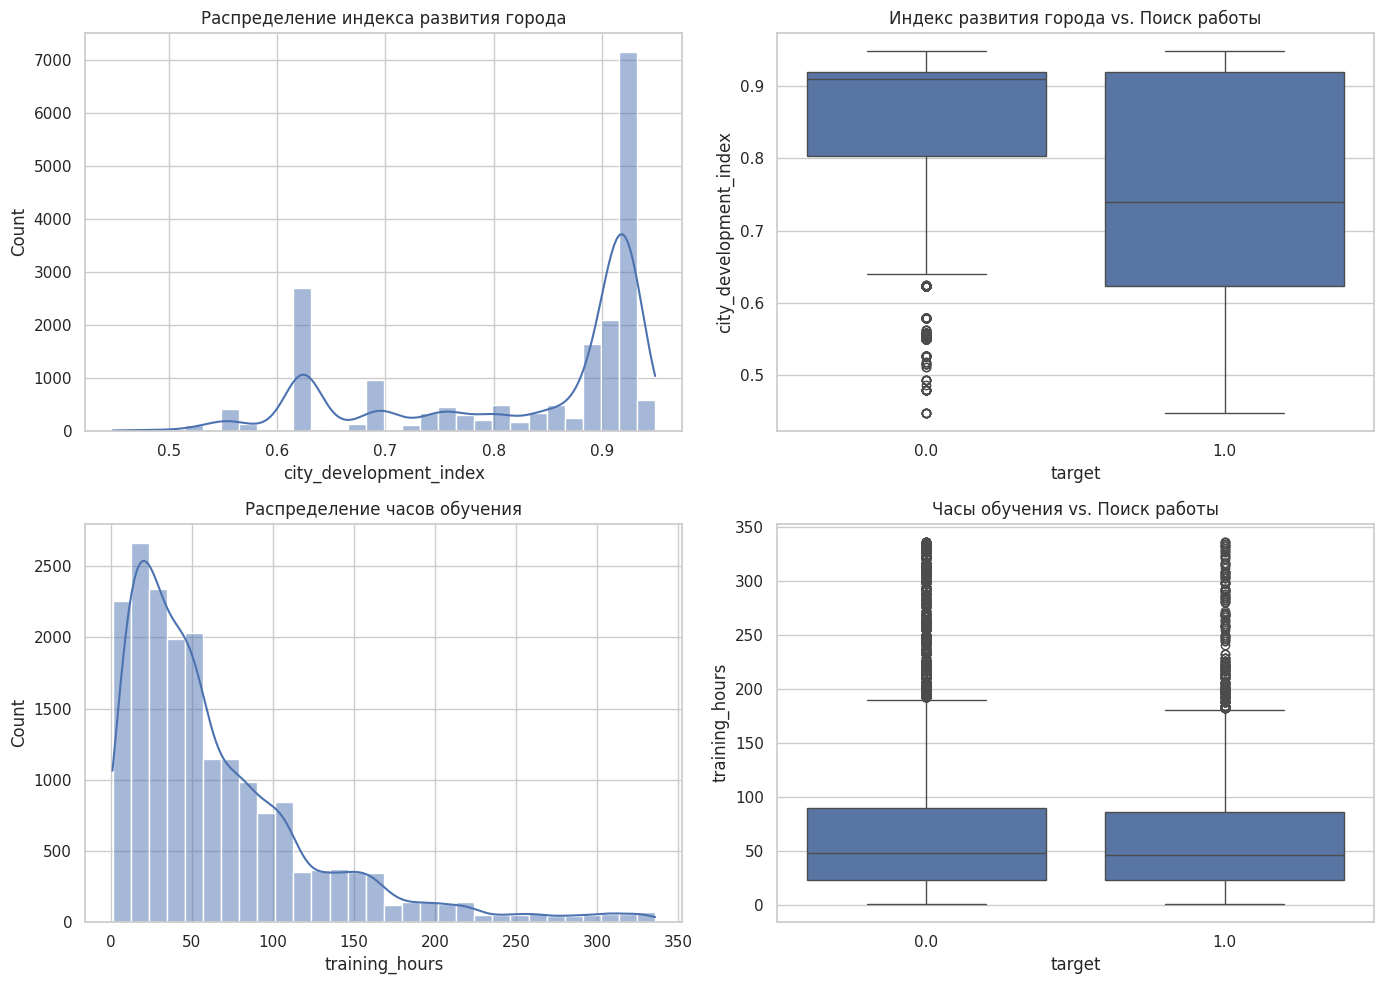

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма для city_development_index
sns.histplot(train_df['city_development_index'], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Распределение индекса развития города')

# Boxplot для city_development_index
sns.boxplot(x=train_df['target'], y=train_df['city_development_index'], ax=axes[0, 1])
axes[0, 1].set_title('Индекс развития города vs. Поиск работы')

# Гистограмма для training_hours
sns.histplot(train_df['training_hours'], bins=30, ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Распределение часов обучения')

# Boxplot для training_hours
sns.boxplot(x=train_df['target'], y=train_df['training_hours'], ax=axes[1, 1])
axes[1, 1].set_title('Часы обучения vs. Поиск работы')

plt.tight_layout()
plt.show()

###Анализ числовых признаков: Ключевые выводы

**`Индекс развития города` (city_development_index)** — ключевой предиктор.

Данные сильно смещены: подавляющее большинство кандидатов из городов с высоким индексом (>0.9).

Наблюдается четкая обратная зависимость: кандидаты, ищущие работу (target=1), в среднем происходят из городов со значительно более низким индексом развития. Этот признак однозначно будет важен для модели.

**`Часы обучения` (training_hours)** — признак с низкой значимостью.
Распределение также сильно смещено: абсолютное большинство кандидатов проходят короткие курсы (< 100 часов), а длинное обучение является редкостью (длинный правый "хвост").
Визуально нет никакой разницы в распределении часов между теми, кто ищет работу, и теми, кто не ищет. Этот признак, скорее всего, обладает слабой предсказательной силой.

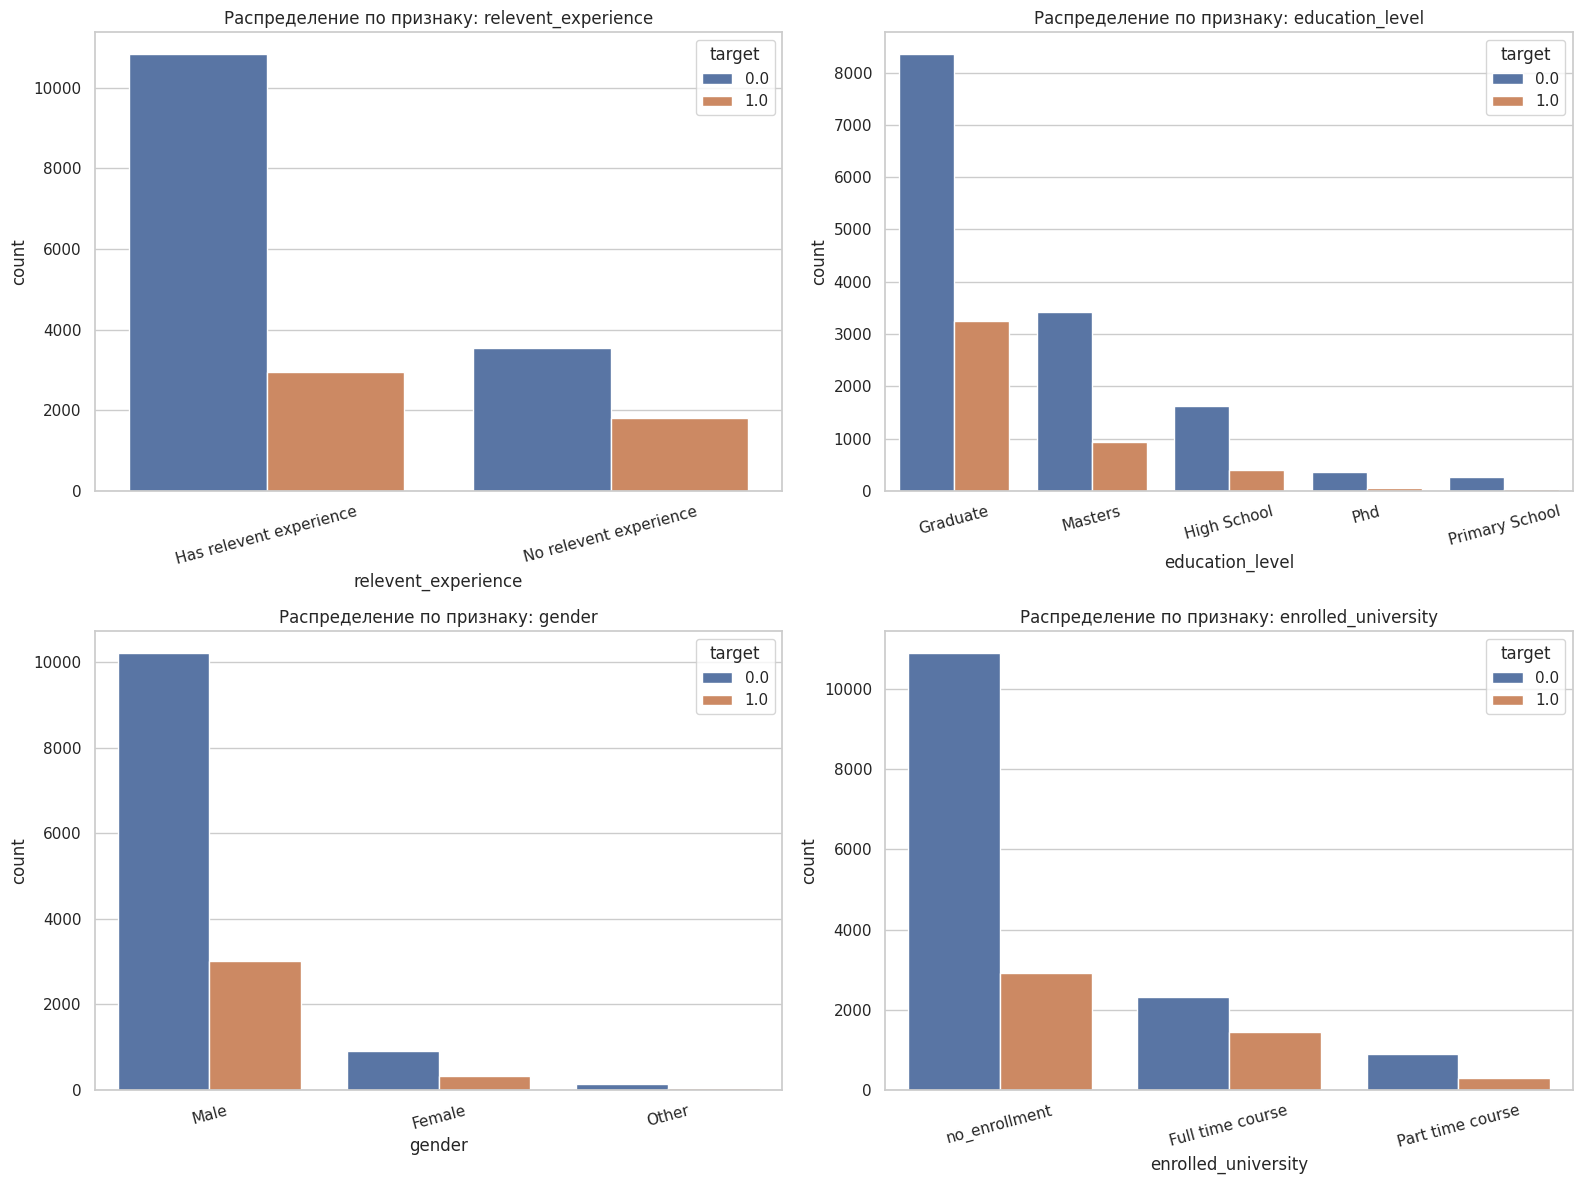

In [125]:
cat_features = ['relevent_experience', 'education_level', 'gender', 'enrolled_university']

plt.figure(figsize=(16, 12))

for i, feature in enumerate(cat_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=train_df, x=feature, hue='target')
    plt.title(f'Распределение по признаку: {feature}')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Анализ категориальных признаков: Ключевые выводы

*   **Релевантный опыт (`relevent_experience`) — самый сильный предиктор.**
    *   Наблюдается очень сильная зависимость: среди кандидатов **без релевантного опыта** доля ищущих работу (`target=1`) непропорционально высока по сравнению с теми, у кого опыт есть. Этот признак будет критически важен для модели.

*   **Уровень образования (`education_level`) и тип зачисления (`enrolled_university`) — умеренно важные признаки.**
    *   Кандидаты с уровнем образования `Graduate` (высшее) и те, кто учится на `Full time course`, показывают более высокую долю желающих сменить работу по сравнению с другими категориями в своих группах.

*   **Пол (`gender`) — признак с низкой значимостью.**
    *   Хотя мужчин в выборке значительно больше, **пропорция** ищущих работу (`target=1`) к не ищущим (`target=0`) практически одинакова для мужчин и женщин. Это говорит о том, что пол вряд ли является значимым фактором для предсказания.

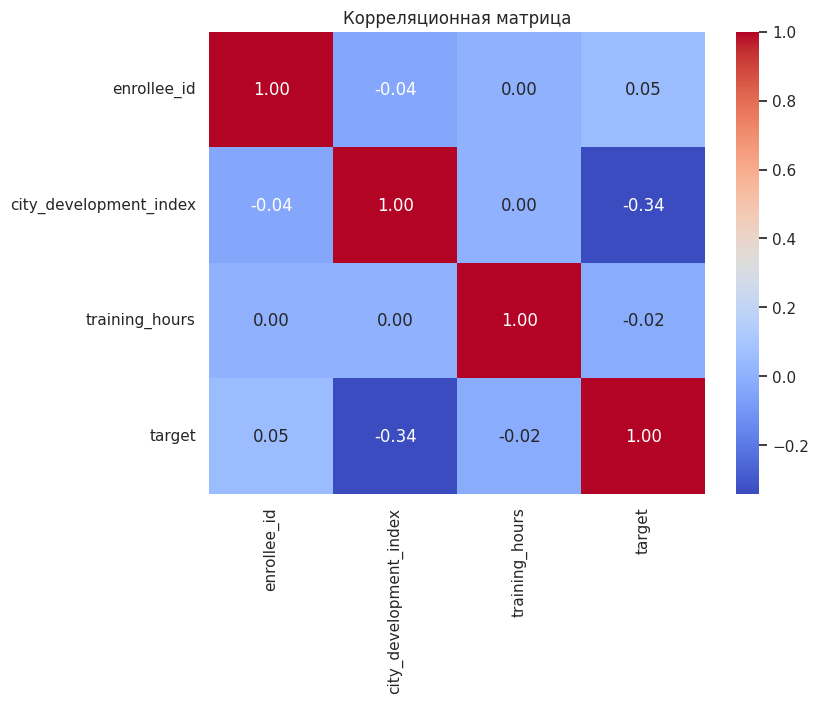

In [126]:
plt.figure(figsize=(8, 6))

corr_matrix = train_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

### Анализ корреляционной матрицы

*   **Основной вывод:** Матрица подтверждает выводы, сделанные на основе визуального анализа. Самая значимая линейная связь наблюдается между целевой переменной `target` и индексом развития города.

*   **`city_development_index` vs `target` (Корреляция -0.34):**
    *   Наблюдается умеренная **отрицательная** корреляция.
    *   **Интерпретация:** Чем **ниже** индекс развития города, тем **выше** вероятность того, что кандидат ищет работу. Это подтверждает, что `city_development_index` является важным предсказательным признаком.

*   **`training_hours` vs `target` (Корреляция -0.02):**
    *   Корреляция практически равна нулю.
    *   **Интерпретация:** Линейная связь между количеством часов обучения и желанием сменить работу отсутствует. Этот признак сам по себе имеет низкую предсказательную ценность.

*   **`enrollee_id`:**
    *   Не имеет значимой корреляции ни с одним из признаков, что логично, так как это просто идентификатор. Этот столбец следует исключить из данных перед обучением модели.

*   **Межпризнаковая корреляция:**
    *   Все числовые признаки между собой не коррелируют (значения близки к 0). Это хорошо, так как они несут в себе независимую информацию и не создают проблему мультиколлинеарности.

## Шаг 4: Пропуски

In [127]:
print("Количество пропусков:")
print(X_train.isnull().sum())
print('-'*40)
print(X_test.isnull().sum())

Количество пропусков:
enrollee_id                  0
city                         0
city_development_index       0
gender                    3574
relevent_experience          0
enrolled_university        317
education_level            362
major_discipline          2258
experience                  50
company_size              4714
company_type              4881
last_new_job               343
training_hours               0
dtype: int64
----------------------------------------
enrollee_id                  0
city                         0
city_development_index       0
gender                     934
relevent_experience          0
enrolled_university         69
education_level             98
major_discipline           555
experience                  15
company_size              1224
company_type              1259
last_new_job                80
training_hours               0
dtype: int64


Для колонок company_type и company_size, где много пропусков, скорее всего, означают отсутствие работы у кандидата, мы создадим отдельную категорию

In [128]:
X_train['company_type'] = X_train['company_type'].fillna('Unknown')
X_train['company_size'] = X_train['company_size'].fillna('Unknown')
X_test['company_type'] = X_test['company_type'].fillna('Unknown')
X_test['company_size'] = X_test['company_size'].fillna('Unknown')


print("\nПропуски в 'company_type' и 'company_size' обработаны.")


Пропуски в 'company_type' и 'company_size' обработаны.


Для всех остальных колонок с пропусками мы применим самый безопасный метод — заполнение модой

In [129]:
cols_to_fill_with_mode = [
    'gender',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'experience',
    'last_new_job'
]


for col in cols_to_fill_with_mode:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Пропуски в X_train и X_test обработаны консистентно.")

Пропуски в X_train и X_test обработаны консистентно.


In [130]:
print("\nКоличество пропусков ПОСЛЕ обработки:")
print(X_train.isnull().sum())
print('-'*40)
print(X_test.isnull().sum())


Количество пропусков ПОСЛЕ обработки:
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64
----------------------------------------
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64


##Шаг 5: Обработка категориальных признаков

In [131]:
# Создадим словари для ручного кодирования
experience_map = {
    '<1': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10,
    '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20,
    '>20': 21
}

education_level_map = {
    'Primary School': 0,
    'High School': 1,
    'Graduate': 2,
    'Masters': 3,
    'Phd': 4
}

company_size_map = {
    'Unknown': 0, '<10': 1, '10/49': 2, '50-99': 3, '100-500': 4,
    '500-999': 5, '1000-4999': 6, '5000-9999': 7, '10000+': 8
}

last_new_job_map = {
    'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5
}

# Непосредственно кодирование
X_train['experience'] = X_train['experience'].map(experience_map)
X_train['education_level'] = X_train['education_level'].map(education_level_map)
X_train['company_size'] = X_train['company_size'].map(company_size_map)
X_train['last_new_job'] = X_train['last_new_job'].map(last_new_job_map)

X_train['relevent_experience'] = X_train['relevent_experience'].replace(
    {'No relevent experience': 0, 'Has relevent experience': 1}
)

X_test['experience'] = X_test['experience'].map(experience_map)
X_test['education_level'] = X_test['education_level'].map(education_level_map)
X_test['company_size'] = X_test['company_size'].map(company_size_map)
X_test['last_new_job'] = X_test['last_new_job'].map(last_new_job_map)

X_test['relevent_experience'] = X_test['relevent_experience'].replace(
    {'No relevent experience': 0, 'Has relevent experience': 1}
)

print("Порядковые признаки успешно закодированы.")

Порядковые признаки успешно закодированы.


/tmp/ipython-input-4054595108.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['relevent_experience'] = X_train['relevent_experience'].replace(
/tmp/ipython-input-4054595108.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['relevent_experience'] = X_test['relevent_experience'].replace(


Удалим колонки enrollee_id и city, так как они не являются полезными признаками в их текущем виде. enrollee_id — это просто идентификатор, а city имеет слишком много уникальных значений (123 города), что создаст 123 новые колонки и сильно усложнит модель

In [132]:
X_train.drop(['enrollee_id', 'city'], axis=1, inplace=True)
X_test.drop(['enrollee_id', 'city'], axis=1, inplace=True)

# Сохраняем индексы, чтобы потом разделить датафреймы обратно
train_index = X_train.index
test_index = X_test.index

# Временно объединяем для консистентного применения get_dummies
temp_df = pd.concat([X_train, X_test], axis=0)

# Применяем get_dummies ОДИН РАЗ к объединенному датафрейму
temp_df_dummies = pd.get_dummies(temp_df, drop_first=True)

# Разделяем обратно на X_train и X_test. Теперь у них гарантированно одинаковые колонки!
X_train = temp_df_dummies.loc[train_index]
X_test = temp_df_dummies.loc[test_index]

In [133]:
print("\nПервые 5 строк датафрейма после кодирования:")
print(X_train.head())

print("\nИнформация о датафрейме после кодирования:")
X_train.info()


Первые 5 строк датафрейма после кодирования:
       city_development_index  relevent_experience  education_level  \
17855                   0.624                    1                2   
17664                   0.920                    0                0   
13404                   0.896                    1                2   
13366                   0.920                    1                2   
15670                   0.855                    1                2   

       experience  company_size  last_new_job  training_hours  gender_Male  \
17855          10             3             1              90         True   
17664           5             0             0              15         True   
13404          12             6             5              36         True   
13366           5             4             1              53         True   
15670           5             0             1             158        False   

       gender_Other  enrolled_university_Part time course 

## Нормализация

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Данные в X_train и X_test успешно масштабированы.")

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\nПервые 5 строк масштабированного X_train:")
print(X_train.head())

Данные в X_train и X_test успешно масштабированы.

Первые 5 строк масштабированного X_train:
   city_development_index  relevent_experience  education_level  experience  \
0               -1.672102             0.623279        -0.194616   -0.023829   
1                0.734358            -1.604419        -3.113096   -0.758066   
2                0.539240             0.623279        -0.194616    0.269865   
3                0.734358             0.623279        -0.194616   -0.758066   
4                0.205913             0.623279        -0.194616   -0.758066   

   company_size  last_new_job  training_hours  gender_Male  gender_Other  \
0      0.019960     -0.589366        0.411648     0.280784     -0.102062   
1     -1.099236     -1.189700       -0.839076     0.280784     -0.102062   
2      1.139157      1.811969       -0.488873     0.280784     -0.102062   
3      0.393026     -0.589366       -0.205376     0.280784     -0.102062   
4     -1.099236     -0.589366        1.545638    -3.

##Шаг 7: Запуск классификатора. Метод k-ближайших соседей (KNN)

Это один из самых простых для понимания алгоритмов. Чтобы определить, к какому классу относится новый объект, он просто смотрит на k самых похожих на него "соседей" из обучающей выборки и предсказывает тот класс, который встречается среди них чаще всего.
Непараметрический метод: KNN не делает никаких предположений о том, как распределены ваши данные.
Это делает его гибким и применимым к широкому кругу задач.
Хорошая отправная точка: Результаты KNN позволяют получить "базовый уровень" качества. Можно использовать его как точку отсчета, чтобы понять, насколько более сложные модели действительно лучше.
Важность нормализации: Этот метод критически чувствителен к масштабу признаков, так как он основан на вычислении "расстояний" между точками. Если один признак измеряется в тысячах, а другой — в долях единицы, то первый будет полностью доминировать при расчете расстояния.

In [135]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("Модель KNeighborsClassifier (k=5) успешно обучена.")

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print("Предсказания для обучающей и тестовой выборок получены.")

Модель KNeighborsClassifier (k=5) успешно обучена.
Предсказания для обучающей и тестовой выборок получены.


##Шаг 8: Вычисление метрик

In [136]:
from sklearn.metrics import classification_report

print("--- Отчет по качеству на ОБУЧАЮЩЕЙ выборке (k=5) ---")
print(classification_report(y_train, y_train_pred))

print("\n--- Отчет по качеству на ТЕСТОВОЙ выборке (k=5) ---")
print(classification_report(y_test, y_test_pred))

--- Отчет по качеству на ОБУЧАЮЩЕЙ выборке (k=5) ---
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89     11504
         1.0       0.69      0.55      0.62      3822

    accuracy                           0.83     15326
   macro avg       0.78      0.74      0.75     15326
weighted avg       0.82      0.83      0.82     15326


--- Отчет по качеству на ТЕСТОВОЙ выборке (k=5) ---
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      2877
         1.0       0.51      0.44      0.47       955

    accuracy                           0.75      3832
   macro avg       0.67      0.65      0.66      3832
weighted avg       0.74      0.75      0.75      3832



### Анализ отчетов о качестве модели (k=5)

#### 1. Общий вывод: Модель переобучена и неэффективна для целевого класса

*   **Наличие переобучения (Overfitting):** Наблюдается значительное падение качества при переходе от обучающей выборки к тестовой. Например, F1-score для класса 1.0 падает с 0.62 до 0.47. Это классический признак того, что модель слишком хорошо "запомнила" тренировочные данные и плохо обобщает закономерности на новых, unseen данных. Значение `k=5`, вероятно, слишком маленькое, что делает модель излишне сложной.

*   **Общая точность (Accuracy) обманчива:** Несмотря на то, что `accuracy` на тесте составляет 75%, эта метрика вводит в заблуждение из-за дисбаланса классов. Модель достигает этого показателя в основном за счет правильного определения доминирующего класса "не ищет работу".

#### 2. Анализ целевого класса (1.0 - "Ищет работу") — самая важная часть

На тестовой выборке производительность модели для нашей главной задачи (поиск кандидатов, готовых сменить работу) очень слабая:

*   **Recall (Полнота) = 0.44:** Это самый критичный показатель. Он означает, что модель находит только 44% всех кандидатов, которые действительно ищут работу. Более половины (56%) целевых кандидатов мы просто упускаем. С точки зрения бизнеса — это огромная потеря потенциальных сотрудников.

*   **Precision (Точность) = 0.51:** Когда модель все-таки помечает кандидата как "ищущего работу", она оказывается права лишь в 51% случаев. Это означает, что почти половина усилий HR-отдела, направленных на этих кандидатов, будет потрачена впустую.

*   **F1-score = 0.47:** Это сводный показатель, который подтверждает низкое качество модели для нашего целевого класса. Он находится в равновесии между низкой точностью и очень низкой полнотой.

#### 3. Анализ мажоритарного класса (0.0 - "Не ищет работу")

*   Модель хорошо справляется с определением кандидатов, которые не ищут работу (`F1-score = 0.84`). Это ожидаемо, так как этих данных гораздо больше, и модели проще научиться предсказывать доминирующий класс.

### Итоговый комментарий

Модель `k-NN` с `k=5` в ее текущем виде не готова к практическому применению. Она переобучена и, что самое важное, катастрофически плохо справляется с основной бизнес-задачей — поиском заинтересованных кандидатов, упуская более половины из них. Следующий шаг — поиск оптимального значения `k` — критически важен. Мы ожидаем, что увеличение `k` снизит переобучение и поможет найти лучший баланс между `precision` и `recall` на тестовых данных.

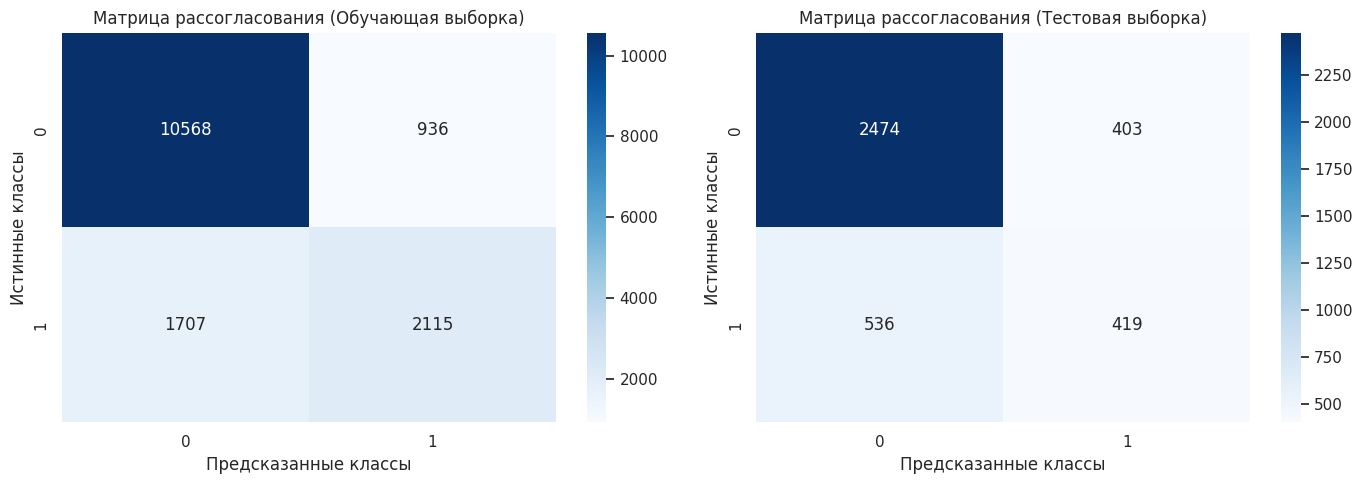

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица рассогласования (Обучающая выборка)')
axes[0].set_xlabel('Предсказанные классы')
axes[0].set_ylabel('Истинные классы')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица рассогласования (Тестовая выборка)')
axes[1].set_xlabel('Предсказанные классы')
axes[1].set_ylabel('Истинные классы')

plt.tight_layout()
plt.show()

### Анализ матриц рассогласования (k=5)

Матрицы рассогласования наглядно подтверждают выводы, сделанные из отчета о качестве. Основное внимание уделим **тестовой выборке**, так как она показывает реальную производительность модели.

#### Ключевые выводы по тестовой матрице:

1.  **Главная проблема — огромное количество пропущенных кандидатов (False Negatives):**
    *   Модель **пропустила 536 кандидатов**, которые на самом деле искали работу (значение в левом нижнем квадрате). Это самая дорогостоящая ошибка для бизнеса, так как это прямая потеря потенциальных сотрудников.

2.  **Модель находит меньше половины целевых кандидатов:**
    *   Из всех, кто действительно искал работу (536 + 419 = 955 человек), модель смогла правильно определить только 419 (True Positives). Это визуальное подтверждение очень низкого показателя `Recall (0.44)`.

3.  **Значительное число "ложных тревог" (False Positives):**
    *   Модель ошибочно пометила 403 кандидата как "ищущих работу", хотя они таковыми не являлись (значение в правом верхнем квадрате). Это приводит к неэффективной трате времени и ресурсов HR-специалистов.

4.  **Сравнение с обучающей выборкой подтверждает переобучение:**
    *   На обучающей выборке модель вела себя схожим образом, но была несколько увереннее в своих предсказаниях (нашла 2115 из 3822 целевых кандидатов). Падение производительности на тестовых данных еще раз указывает на то, что модель плохо обобщает полученные знания.

#### Итоговый комментарий

Матрица рассогласования для тестовой выборки безжалостно показывает, почему модель с `k=5` не годится для решения поставленной задачи. Она пропускает больше целевых кандидатов, чем находит, и при этом создает большое количество ложных срабатыбатываний. Наша основная цель при подборе оптимального `k` — значительно уменьшить число в левом нижнем квадрате (536), пусть даже ценой небольшого увеличения числа в правом верхнем (403).

Проверяю 1 соседей:
F1-score на обучающей выборке (k=1): 0.9965
F1-score на тестовой выборке (k=1): 0.4385
Проверяю 3 соседей:
F1-score на обучающей выборке (k=3): 0.6810
F1-score на тестовой выборке (k=3): 0.4706
Проверяю 5 соседей:
F1-score на обучающей выборке (k=5): 0.6155
F1-score на тестовой выборке (k=5): 0.4716
Проверяю 7 соседей:
F1-score на обучающей выборке (k=7): 0.5854
F1-score на тестовой выборке (k=7): 0.4841
Проверяю 9 соседей:
F1-score на обучающей выборке (k=9): 0.5583
F1-score на тестовой выборке (k=9): 0.4841
Проверяю 11 соседей:
F1-score на обучающей выборке (k=11): 0.5485
F1-score на тестовой выборке (k=11): 0.4788
Проверяю 13 соседей:
F1-score на обучающей выборке (k=13): 0.5350
F1-score на тестовой выборке (k=13): 0.4776
Проверяю 15 соседей:
F1-score на обучающей выборке (k=15): 0.5269
F1-score на тестовой выборке (k=15): 0.4716
Проверяю 17 соседей:
F1-score на обучающей выборке (k=17): 0.5224
F1-score на тестовой выборке (k=17): 0.4826
Проверяю 19 соседей:
F1-s

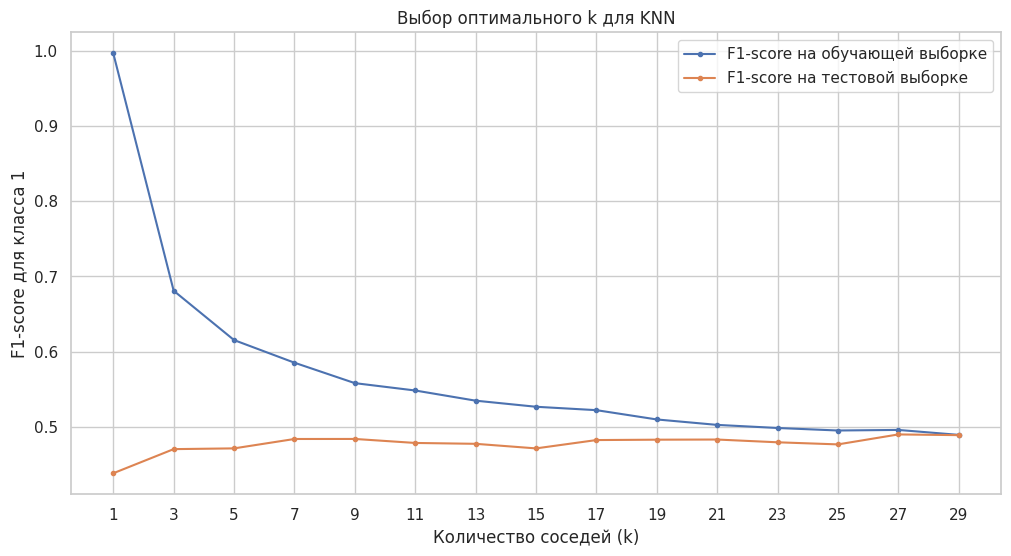

In [138]:
from sklearn.metrics import f1_score

k_range = range(1, 31, 2)

train_scores = []
test_scores = []

for k in k_range:
    print(f"Проверяю {k} соседей:")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred_loop = knn.predict(X_train)
    y_test_pred_loop = knn.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred_loop, pos_label=1)
    test_f1 = f1_score(y_test, y_test_pred_loop, pos_label=1)
    print(f"F1-score на обучающей выборке (k={k}): {train_f1:.4f}")
    print(f"F1-score на тестовой выборке (k={k}): {test_f1:.4f}")
    train_scores.append(train_f1)
    test_scores.append(test_f1)

optimal_k = k_range[test_scores.index(max(test_scores))]
print(f"Оптимальное значение k: {optimal_k}")
print(f"Максимальный F1-score на тестовой выборке: {max(test_scores):.4f}")

plt.figure(figsize=(12, 6))
plt.plot(k_range, train_scores, label='F1-score на обучающей выборке', marker='.')
plt.plot(k_range, test_scores, label='F1-score на тестовой выборке', marker='.')
plt.title('Выбор оптимального k для KNN')
plt.xlabel('Количество соседей (k)')
plt.ylabel('F1-score для класса 1')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

In [139]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=27)

knn.fit(X_train, y_train)

print("Модель KNeighborsClassifier (k=27) успешно обучена.")

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print("Предсказания для обучающей и тестовой выборок получены.")

Модель KNeighborsClassifier (k=27) успешно обучена.
Предсказания для обучающей и тестовой выборок получены.


In [140]:
from sklearn.metrics import classification_report

print("--- Отчет по качеству на ОБУЧАЮЩЕЙ выборке (k=27) ---")
print(classification_report(y_train, y_train_pred))

print("\n--- Отчет по качеству на ТЕСТОВОЙ выборке (k=27) ---")
print(classification_report(y_test, y_test_pred))

--- Отчет по качеству на ОБУЧАЮЩЕЙ выборке (k=27) ---
              precision    recall  f1-score   support

         0.0       0.82      0.91      0.87     11504
         1.0       0.62      0.42      0.50      3822

    accuracy                           0.79     15326
   macro avg       0.72      0.66      0.68     15326
weighted avg       0.77      0.79      0.77     15326


--- Отчет по качеству на ТЕСТОВОЙ выборке (k=27) ---
              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86      2877
         1.0       0.57      0.43      0.49       955

    accuracy                           0.78      3832
   macro avg       0.70      0.66      0.67      3832
weighted avg       0.76      0.78      0.77      3832



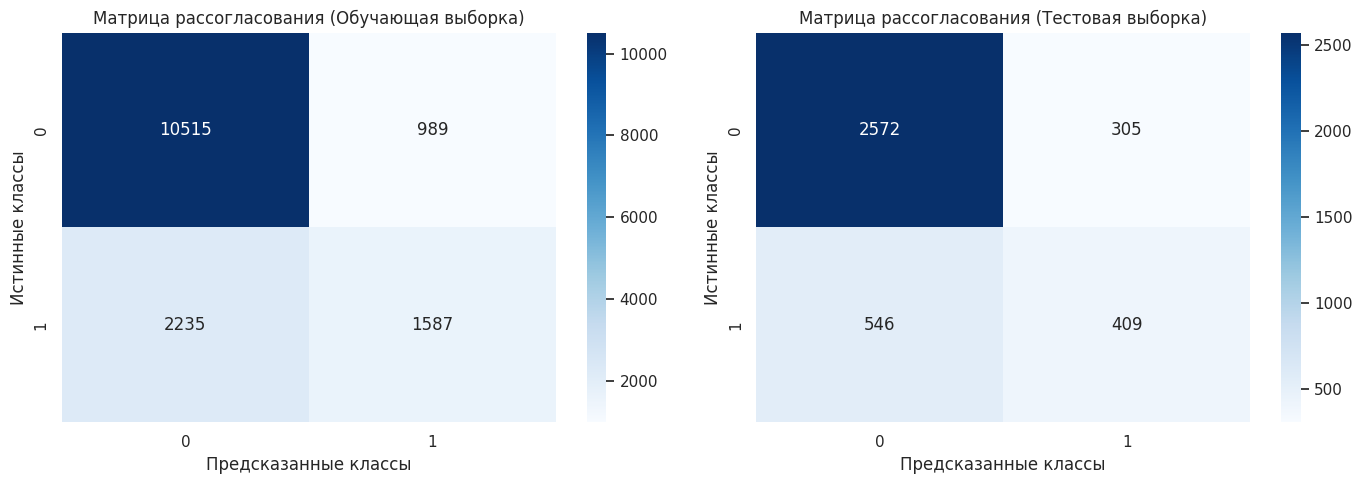

In [141]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица рассогласования (Обучающая выборка)')
axes[0].set_xlabel('Предсказанные классы')
axes[0].set_ylabel('Истинные классы')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица рассогласования (Тестовая выборка)')
axes[1].set_xlabel('Предсказанные классы')
axes[1].set_ylabel('Истинные классы')

plt.tight_layout()
plt.show()

### Анализ результатов модели при k=27 (Оптимальное значение)

#### 1. Главный вывод: Модель стала значительно лучше, стабильнее и надежнее

Выбор `k=27` является большим шагом вперед. Модель избавилась от ключевой проблемы — переобучения, и теперь демонстрирует более сбалансированное и практически применимое качество, несмотря на некоторые компромиссы.

#### 2. Проблема переобучения решена

*   **Сравнение F1-score (класс 1.0):**
    *   При `k=5`: Разрыв между Обучающей (0.62) и Тестовой (0.47) выборками был огромным (0.15).
    *   При `k=27`: Разрыв между Обучающей (0.50) и Тестовой (0.49) выборками практически отсутствует (0.01).
*   **Вывод:** Это означает, что модель с `k=27` отлично обобщает данные. Ее производительность на новых, невиданных данных почти такая же, как на тех, на которых она училась. Это делает модель надежной и предсказуемой.

#### 3. Анализ ключевого компромисса: Точность (Precision) в обмен на Полноту (Recall)

При увеличении `k` модель стала более "осторожной". Она делает меньше предсказаний в пользу класса `1.0`, но делает их более качественно.

*   **Точность (Precision) значительно выросла (с 0.51 до 0.57):**
    *  Теперь, если модель помечает кандидата как "ищущего работу", она права в 57% случаев (вместо 51%).
    *  Количество "ложных тревог" (False Positives) упало с 403 до 305. Это очень хороший результат. HR-отдел будет тратить значительно меньше времени на кандидатов, которые на самом деле не заинтересованы.

*   **Полнота (Recall) незначительно снизилась (с 0.44 до 0.43):**
    *  Модель стала находить чуть меньший процент от общего числа заинтересованных кандидатов.
    *  Количество пропущенных кандидатов (False Negatives) незначительно выросло с 536 до 546. Мы упускаем на 10 кандидатов больше, чем раньше.

#### 4. Общая эффективность (F1-score) выросла

*   Несмотря на небольшое падение `Recall`, F1-score для класса 1.0 на тестовой выборке вырос с 0.47 до 0.49. Это говорит о том, что существенный выигрыш в точности оказался более ценным, чем минимальный проигрыш в полноте. Модель стала более сбалансированной.

### Итоговый комментарий

Модель с `k=27` является однозначно лучшим выбором. Она решает главную проблему переобучения, что делает ее результаты стабильными и заслуживающими доверия. С точки зрения бизнеса, она позволяет сократить ненужные расходы (меньше ложных срабатываний), хоть и ценой минимального увеличения числа упущенных кандидатов. Это разумный и оправданный компромисс, который делает модель гораздо более полезной на практике.

### 12. Общие выводы по датасету

Была успешно решена задача бинарной классификации для прогнозирования смены работы кандидатами на курсах Data Science. Был пройден полный цикл машинного обучения: от анализа и предобработки данных до построения, оценки и оптимизации модели.

#### Ключевые инсайты из данных:

*   **Наиболее сильными предикторами** желания сменить работу являются **отсутствие релевантного опыта** и проживание в **городе с низким индексом развития**. Эти два фактора являются доминирующими.
*   Признаки, такие как **количество часов обучения** и **пол**, показали очень слабую предсказательную силу.
*   Данные характеризуются **сильным дисбалансом классов**: только ~25% кандидатов ищут работу, что требует особого внимания при оценке качества модели и является основной причиной, почему метрика `accuracy` не показательна.

#### Построение и оптимизация модели:

*   В качестве базовой модели был выбран **метод k-ближайших соседей (KNN)** как простой и интуитивно понятный алгоритм, чувствительный к качеству предобработки данных.
*   Первоначальная модель с `k=5` продемонстрировала **сильное переобучение** и низкую эффективность на тестовых данных (`F1-score` для целевого класса = 0.47), упуская более половины (56%) всех заинтересованных кандидатов.
*   Путем подбора гиперпараметров было найдено **оптимальное значение `k=27`**. Новая модель решила проблему переобучения (результаты на обучающей и тестовой выборках почти идентичны) и показала более сбалансированное качество (`F1-score` = 0.49). Ключевым улучшением стало **повышение точности (Precision) до 0.57**, что снизило количество "ложных тревог" и сделало модель более эффективной с точки зрения затрат ресурсов.

#### Практическая ценность и дальнейшие шаги:

*   **Ценность:** Разработанная модель, несмотря на ее ограничения, может быть использована как **инструмент первого уровня для скоринга кандидатов**. Она позволяет HR-отделу приоритизировать усилия и сосредоточиться на группе с наибольшей вероятностью заинтересованности, что эффективнее случайного выбора.

*   **Ограничения:** Модель все еще **пропускает около 57% целевых кандидатов** (`Recall` = 0.43). Это означает, что она не должна быть единственным инструментом, а лишь вспомогательным.

*   **Возможный вектор улучшения:**
    1.  **Использовать более сложные модели:** Алгоритмы, такие как **Логистическая регрессия, Случайный лес или Градиентный бустинг**, могут уловить более сложные зависимости в данных и, вероятно, покажут лучший результат.
    2.  **Применить техники борьбы с дисбалансом:** Использование техник, таких как **SMOTE** (для генерации синтетических примеров меньшинства) или использование параметра `class_weight='balanced'` в других моделях, может значительно улучшить полноту (`Recall`).
    3.  **Более глубокое Feature Engineering:** Можно попробовать сгенерировать новые признаки, например, сгруппировать города по уровню развития вместо их полного удаления.